
# Implicitation Study: Analysis of the 7 Core German Adjectives
### (gut, wichtig, glücklich, richtig, falsch, schlecht, verschieden)

This notebook analyses the special **implicitation dataset**: sentences where an English
source adjective was translated into German using one of the 7 core adjectives, but the
source adjective is generally **not** the "default" one-to-one equivalent of that German word
(e.g. not *important → wichtig*, but *essential → wichtig*; not *good → gut*, but *great → gut*).

The idea behind this special dataset is to zoom in on cases where a translator chose a more
general/basic evaluative German adjective for a more specific English one — a pattern that,
when it shifts the evaluative meaning, is coded here as **implicitation** (or, less often,
**explicitation**).

**Data**: 7 Excel files (one per adjective), each containing token-level annotations:
domain, gender of speaker, the English sentence/lemma, the aligned German sentence/lemma,
evaluativity and attitude-type coding (Appreciation / Judgement / Affect, following an
Appraisal-style framework) for both languages, and two translation-shift columns:
`Translation_strategy` (Equivalence vs. Alteration) and `Translationese_effect`
(Implicitation / Explicitation, coded only when the meaning shifted).

**What this notebook does, task by task:**
1. Load & combine the 7 files into one working dataset
2. Overview of the sample (size, domains, speaker gender)
3. Which English adjectives get "levelled" into each German core adjective
4. A sanity check for accidental equivalence pairs in this "non-equivalent" dataset
5. Translation strategy (Equivalence vs. Alteration) per adjective
6. Translationese effect — the key variable — frequency & proportions per adjective
7. How strategy and effect relate to each other
8. Whether evaluative meaning is preserved or lost across EN → DE
9. Whether the *type* of attitude (Appreciation/Judgement/Affect) shifts, and how implicitation relates to attitude type
10. Domain-wise implicitation rates
11. Gender-wise implicitation rates
12. Export of summary tables (for reporting / for the write-up)
13. A ready-made template for later comparing these results against the **normal** (non-implicitation) dataset of the same 7 adjectives

Run all cells top to bottom. All output tables are also written to `/mnt/user-data/outputs/`
as CSV files so they can be reused in the final write-up.



## 0. Setup

Import the libraries we need and set a consistent, readable plotting style. We also define
the list of the 7 target adjectives (this fixes the order they appear in throughout all
charts and tables) and a lookup of what each adjective's "default"/expected one-to-one
English equivalent would be — we'll use that lookup in Task 4 as a sanity check.


In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Folder containing the 7 Excel files (ships alongside this notebook)
DATA_DIR = "German translations - data for implicitation study"

# Fixed order used throughout the notebook (matches the 7 core adjectives of the wider project)
TARGET_ADJECTIVES = ["gut", "wichtig", "glücklich", "richtig", "falsch", "schlecht", "verschieden"]

# The "default"/expected one-to-one English equivalent of each German core adjective.
# Used only as a sanity check in Task 4 — this implicitation dataset is specifically meant
# to EXCLUDE these default pairs (e.g. we expect "great -> gut", not "good -> gut").
DEFAULT_EQUIVALENT = {
    "gut": "good",
    "wichtig": "important",
    "glücklich": "happy",
    "richtig": "right",
    "falsch": "wrong",
    "schlecht": "bad",
    "verschieden": "different",
}

OUTPUT_DIR = "/mnt/user-data/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)



## 1. Load and combine the 7 files

Each Excel file corresponds to one target adjective and has an identical column structure.
We load all 7, tag every row with which target adjective it belongs to (`target_adjective`),
and concatenate them into a single working DataFrame (`df`). This combined table is what the
rest of the notebook works from.


In [2]:

frames = []
for adj in TARGET_ADJECTIVES:
    path = os.path.join(DATA_DIR, f"{adj}_Bianca.xlsx")
    d = pd.read_excel(path)
    d["target_adjective"] = adj
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

print(f"Combined dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Combined dataset: 489 rows, 18 columns


,file,Domain,Gender,sent_index,token_id,token_form,token_lemma,sentence,EN_Evaluative?,EN_Attitude_type,de_aligned_forms,de_aligned_lemmas,de_sentence,DE_Evaluative?,DE_Attitude_type,Translation_strategy,Translationese_effect,target_adjective
0,Art11_en.conllu,Art,M,92,17,greatest,great,"I kept making comics , and at the Worcester Ar...",Evaluative,Appreciation,besten,gut,"Ich machte weiter Comics , und in dem Worceste...",Evaluative,Appreciation,NaN,NaN,gut
1,Art11_en.conllu,Art,M,93,14,dear,dear,"Mark Lynch , he 's an amazing teacher and he '...",Non-evaluative,NaN,guter,gut,"Mark Lynch , ein erstaunlicher Lehrer , der na...",Non-evaluative,NaN,NaN,NaN,gut
2,Art12_en.conllu,Art,M,107,4,timely,timely,That 's not timely .,Evaluative,Appreciation,grad gut,grad gut,Das passt grad nicht so gut .,Evaluative,Appreciation,Equivalence,NaN,gut
3,Art12_en.conllu,Art,M,111,3,timely,timely,I became timely .,Evaluative-not_speaker,Judgement,ganz gut,ganz gut,"Ich "" passte "" plötzlich ganz gut .",Evaluative-not_speaker,Judgement,Equivalence,NaN,gut
4,Art12_en.conllu,Art,M,120,12,high,high,"It 's 3D CGI , which is going to be very high ...",Evaluative,Appreciation,gute,gut,"Es ist 3D CGI , was eine sehr gute Qualität ha...",Evaluative,Appreciation,Equivalence,NaN,gut



## 2. Dataset overview

How many annotated tokens does each of the 7 target adjectives contribute? This matters
because the adjectives are very unevenly represented in this dataset (e.g. *verschieden*
has far more tokens than *glücklich*), which we need to keep in mind when comparing rates
across adjectives later — small-n adjectives (like *glücklich*, n=3) will be noisy.


,n_tokens
target_adjective,
gut,112
wichtig,69
glücklich,3
richtig,44
falsch,32
schlecht,44
verschieden,185


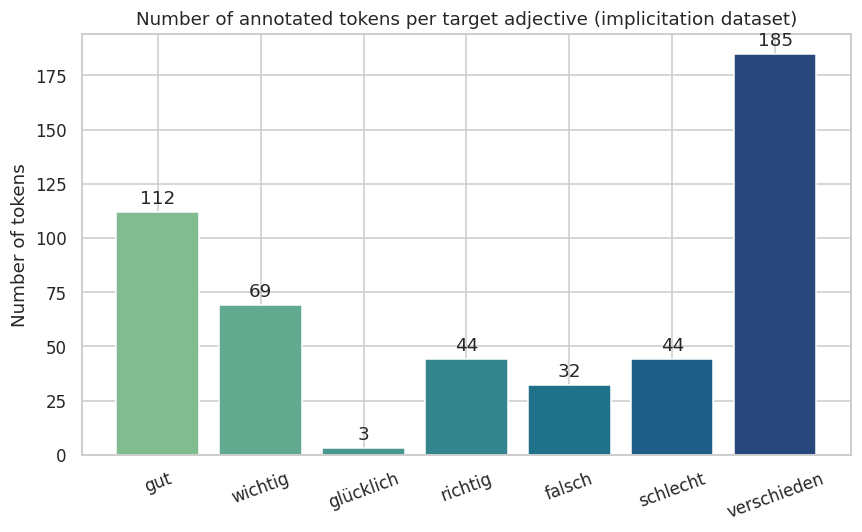

In [3]:

counts = df["target_adjective"].value_counts().reindex(TARGET_ADJECTIVES)
display(counts.to_frame("n_tokens"))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("crest", len(counts)))
ax.set_title("Number of annotated tokens per target adjective (implicitation dataset)")
ax.set_ylabel("Number of tokens")
ax.bar_label(bars, padding=3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task2_tokens_per_adjective.png"))
plt.show()



## 3. Domain and speaker-gender distribution

The talks these sentences come from are tagged by subject domain (e.g. Art, Business,
Education, Technology...) and by the gender of the speaker. A quick look at these
distributions tells us whether the implicitation dataset is skewed toward particular
domains/speakers, which is useful context for interpreting the domain- and gender-level
results in Tasks 10–11.


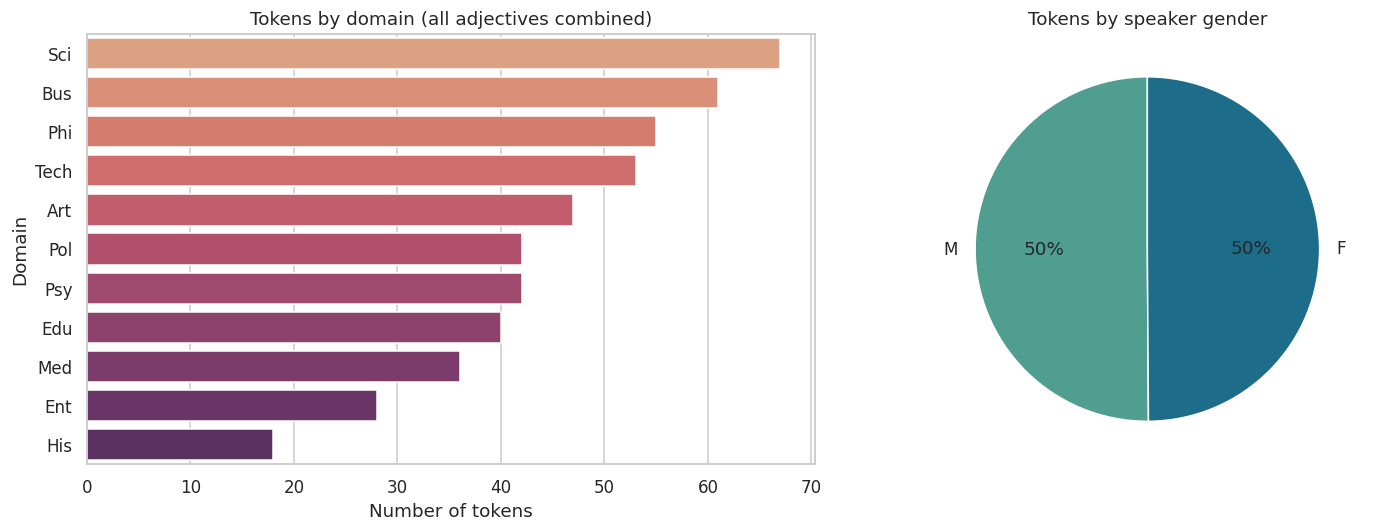

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

domain_counts = df["Domain"].value_counts()
sns.barplot(x=domain_counts.values, y=domain_counts.index, ax=axes[0],
            hue=domain_counts.index, palette="flare", legend=False)
axes[0].set_title("Tokens by domain (all adjectives combined)")
axes[0].set_xlabel("Number of tokens")
axes[0].set_ylabel("Domain")

gender_counts = df["Gender"].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.0f%%",
            colors=sns.color_palette("crest", len(gender_counts)), startangle=90)
axes[1].set_title("Tokens by speaker gender")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task3_domain_gender.png"))
plt.show()



## 4. Which English adjectives get "levelled" into each German core adjective?

This is the heart of what makes this dataset special: for each target German adjective, what
range of English source adjectives (`token_lemma`) get translated into it? A wide, varied set
of source lemmas (e.g. *great, fine, nice, dear, smart...* all becoming *gut*) is itself
evidence of a "levelling"/implicitation pattern — many distinct, more specific English
meanings collapsing onto one general-purpose German adjective.

For each adjective we report (a) how many distinct English lemmas feed into it, and
(b) the most frequent ones.


In [5]:

diversity_rows = []
for adj in TARGET_ADJECTIVES:
    sub = df[df["target_adjective"] == adj]
    n_types = sub["token_lemma"].nunique()
    n_tokens = len(sub)
    diversity_rows.append({
        "target_adjective": adj,
        "n_tokens": n_tokens,
        "n_distinct_EN_lemmas": n_types,
        "type_token_ratio": round(n_types / n_tokens, 2) if n_tokens else np.nan,
    })
diversity = pd.DataFrame(diversity_rows).set_index("target_adjective").reindex(TARGET_ADJECTIVES)
display(diversity)
diversity.to_csv(os.path.join(OUTPUT_DIR, "task4_source_lemma_diversity.csv"))


,n_tokens,n_distinct_EN_lemmas,type_token_ratio
target_adjective,,,
gut,112,57,0.51
wichtig,69,35,0.51
glücklich,3,3,1.00
richtig,44,25,0.57
falsch,32,15,0.47
schlecht,44,24,0.55
verschieden,185,14,0.08


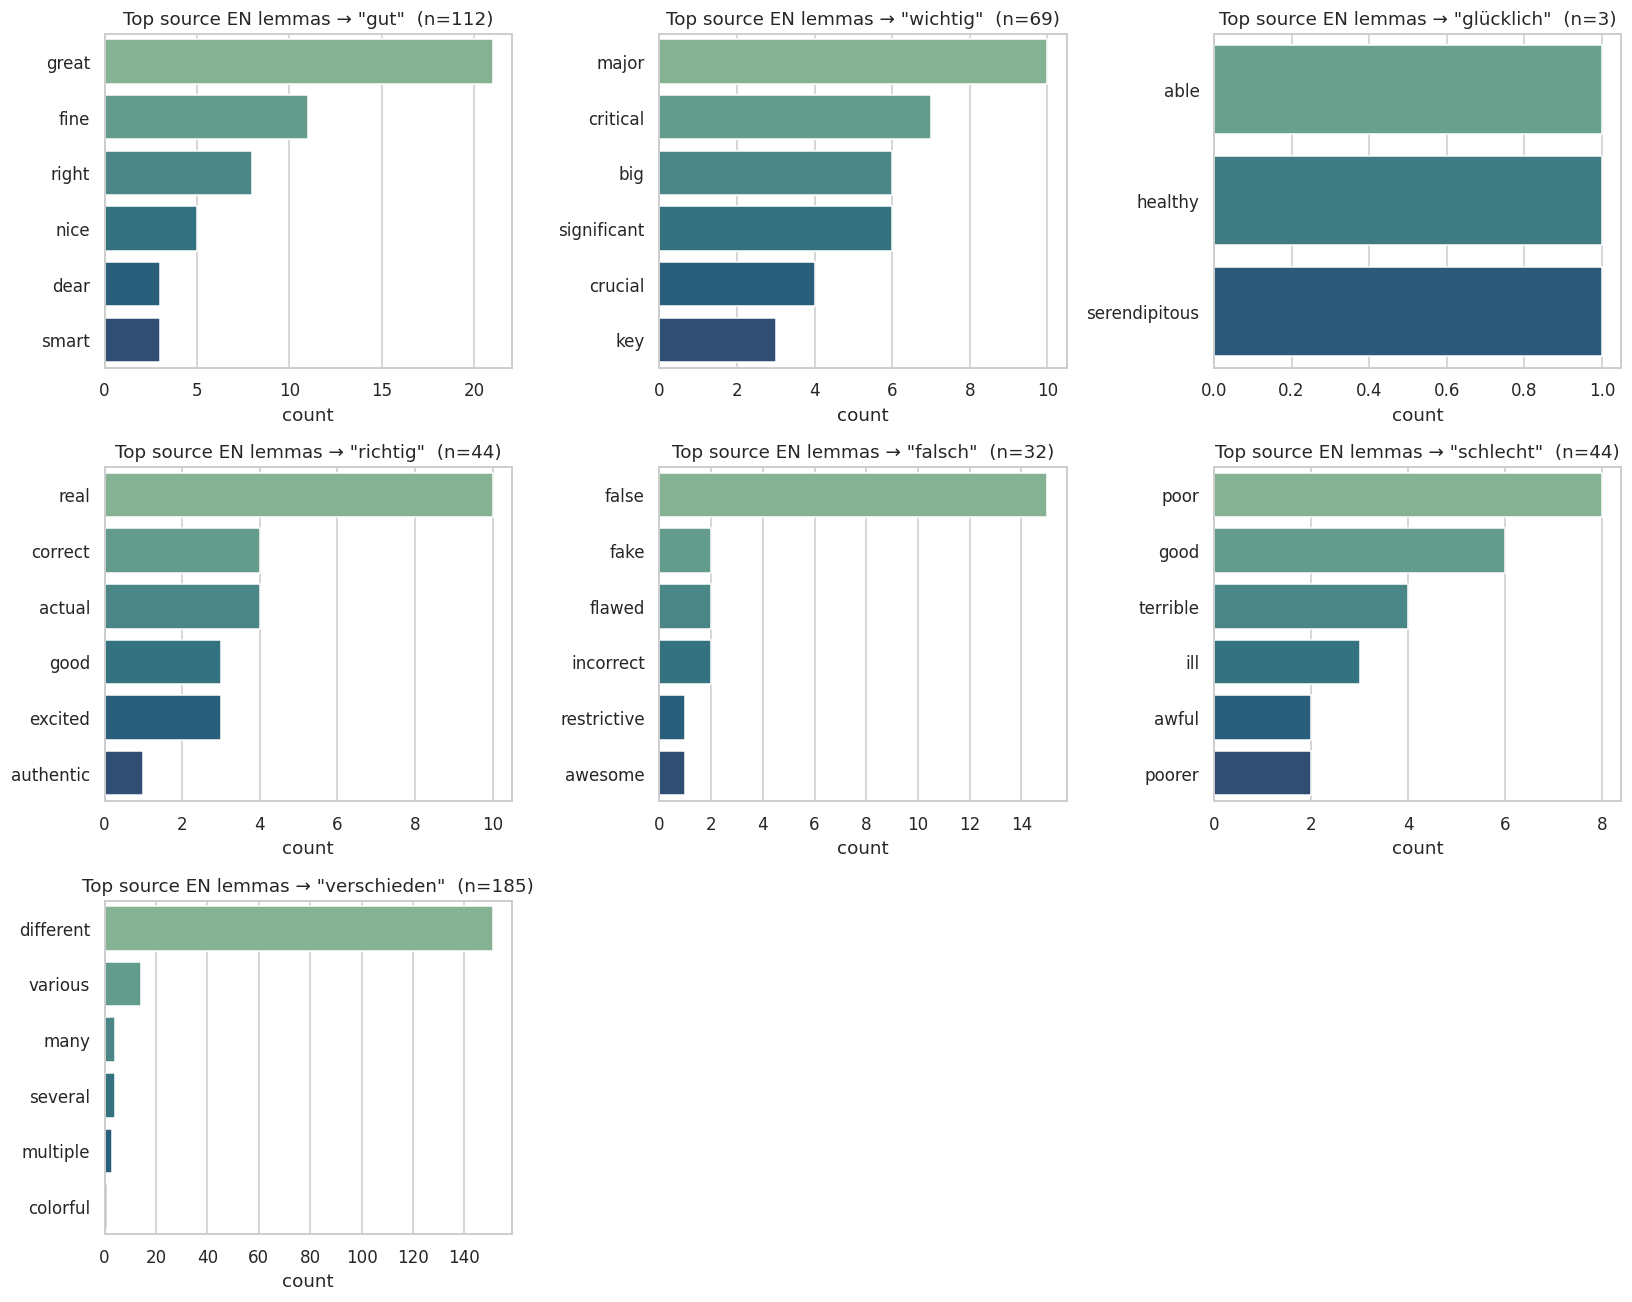

In [6]:

# Small multiples: top 6 source EN lemmas feeding into each target adjective
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, adj in enumerate(TARGET_ADJECTIVES):
    sub = df[df["target_adjective"] == adj]
    top = sub["token_lemma"].value_counts().head(6)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], hue=top.index,
                palette="crest", legend=False)
    axes[i].set_title(f'Top source EN lemmas → "{adj}"  (n={len(sub)})')
    axes[i].set_xlabel("count")
    axes[i].set_ylabel("")

for j in range(len(TARGET_ADJECTIVES), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task4_top_source_lemmas.png"))
plt.show()



## 5. Sanity check: does the dataset accidentally contain "default" equivalence pairs?

The dataset is intended to *exclude* the direct, default English–German equivalence pairs
(good–gut, important–wichtig, happy–glücklich, right–richtig, wrong–falsch, bad–schlecht,
different–verschieden), since those belong to the "normal" translations dataset, not this
implicitation-focused one. We check how often the source lemma (`token_lemma`) nonetheless
equals that default equivalent, per adjective.

**Note:** as the chart below shows, *verschieden* is a clear outlier — a large majority of
its rows have `different` as the source lemma, i.e. the expected direct equivalence pair.
This is worth flagging to whoever curated the file, since (unlike the other 6 adjectives)
it doesn't match the "non-equivalent source" definition of this dataset. The rest of the
notebook still runs on the full data, but keep this in mind when reading any *verschieden*
results — they will look different from what a "pure" implicitation subset would show, unless
these equivalence rows are removed at some later stage in this study.


,expected_default_EN_equivalent,n_rows_with_default_equivalent,n_total_rows,pct_default_equivalent
target_adjective,,,,
gut,good,0,112,0.0
wichtig,important,1,69,1.4
glücklich,happy,0,3,0.0
richtig,right,0,44,0.0
falsch,wrong,1,32,3.1
schlecht,bad,0,44,0.0
verschieden,different,151,185,81.6


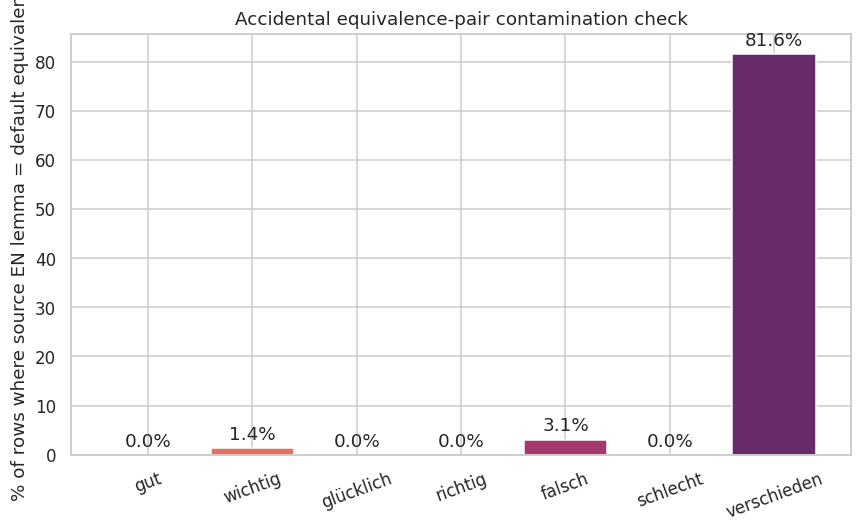

In [7]:

sanity_rows = []
for adj in TARGET_ADJECTIVES:
    sub = df[df["target_adjective"] == adj]
    default_eq = DEFAULT_EQUIVALENT[adj]
    n_default = (sub["token_lemma"].str.lower() == default_eq).sum()
    sanity_rows.append({
        "target_adjective": adj,
        "expected_default_EN_equivalent": default_eq,
        "n_rows_with_default_equivalent": n_default,
        "n_total_rows": len(sub),
        "pct_default_equivalent": round(100 * n_default / len(sub), 1) if len(sub) else np.nan,
    })
sanity = pd.DataFrame(sanity_rows).set_index("target_adjective")
display(sanity)
sanity.to_csv(os.path.join(OUTPUT_DIR, "task5_equivalence_contamination_check.csv"))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sanity.index, sanity["pct_default_equivalent"],
              color=sns.color_palette("flare", len(sanity)))
ax.set_ylabel("% of rows where source EN lemma = default equivalent")
ax.set_title("Accidental equivalence-pair contamination check")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task5_equivalence_contamination.png"))
plt.show()



## 6. Translation strategy: Equivalence vs. Alteration

`Translation_strategy` codes whether the *evaluative meaning* of the sentence was preserved
across the translation (**Equivalence**) or changed (**Alteration**) — independent of whether
the exact same lemma was used. Rows with a missing value are cases the annotator left
uncoded (a small residual category — reported separately below rather than silently dropped).
This tells us, per target adjective, how often translators' word choice actually changed the
evaluative meaning versus keeping it equivalent.


Translation_strategy_,Alteration,Equivalence,Not coded
target_adjective,,,
gut,28,65,19
wichtig,19,50,0
glücklich,0,2,1
richtig,3,38,3
falsch,3,26,3
schlecht,13,24,7
verschieden,14,168,3


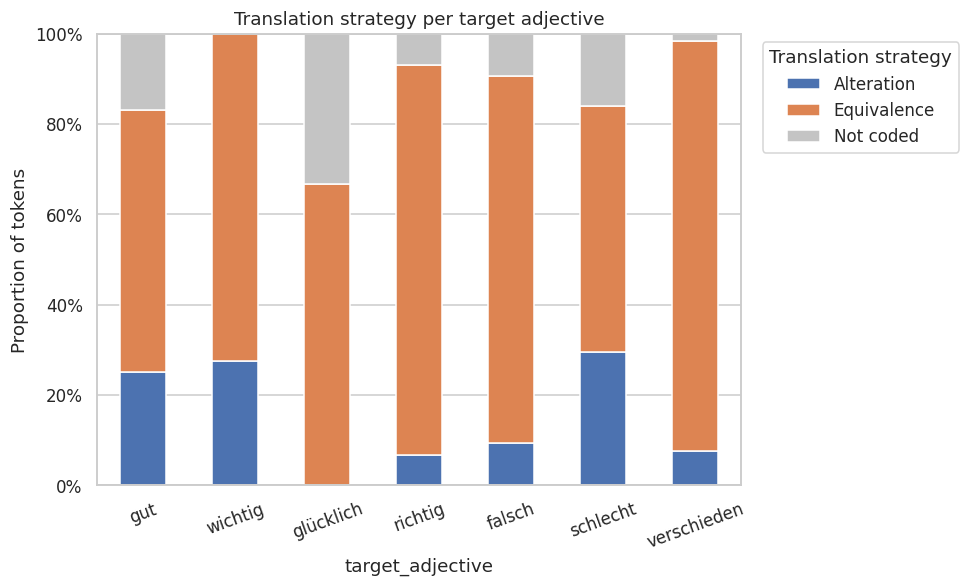

In [8]:

strat = df.copy()
strat["Translation_strategy_"] = strat["Translation_strategy"].fillna("Not coded")

strat_ct = pd.crosstab(strat["target_adjective"], strat["Translation_strategy_"])
strat_ct = strat_ct.reindex(TARGET_ADJECTIVES)
display(strat_ct)
strat_ct.to_csv(os.path.join(OUTPUT_DIR, "task6_translation_strategy_counts.csv"))

strat_prop = strat_ct.div(strat_ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 5.5))
strat_prop.plot(kind="bar", stacked=True, ax=ax,
                 color=["#4C72B0", "#DD8452", "#C4C4C4"])
ax.set_ylabel("Proportion of tokens")
ax.set_title("Translation strategy per target adjective")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title="Translation strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task6_translation_strategy.png"))
plt.show()



## 7. Translationese effect — Implicitation vs. Explicitation (the key variable)

This is the central variable for the implicitation study: whenever `Translation_strategy`
is *Alteration*, `Translationese_effect` records whether that alteration made the evaluative
meaning **more implicit** (Implicitation — a more general/basic word standing in for a more
specific one) or **more explicit** (Explicitation). Rows with no effect coded are cases with
no alteration (mostly Equivalence rows) and are labelled "None" below rather than dropped, so
that percentages are computed over the full dataset per adjective.


In [9]:

eff = df.copy()
eff["Translationese_effect_"] = eff["Translationese_effect"].fillna("None")

eff_ct = pd.crosstab(eff["target_adjective"], eff["Translationese_effect_"])
eff_ct = eff_ct.reindex(TARGET_ADJECTIVES)[["Implicitation", "Explicitation", "None"]]
display(eff_ct)
eff_ct.to_csv(os.path.join(OUTPUT_DIR, "task7_translationese_effect_counts.csv"))

eff_prop = eff_ct.div(eff_ct.sum(axis=1), axis=0)
eff_prop.to_csv(os.path.join(OUTPUT_DIR, "task7_translationese_effect_proportions.csv"))
display(eff_prop.round(3))


Translationese_effect_,Implicitation,Explicitation,None
target_adjective,,,
gut,25,4,83
wichtig,17,2,50
glücklich,0,0,3
richtig,2,1,41
falsch,1,2,29
schlecht,12,1,31
verschieden,12,2,171


Translationese_effect_,Implicitation,Explicitation,None
target_adjective,,,
gut,0.223,0.036,0.741
wichtig,0.246,0.029,0.725
glücklich,0.000,0.000,1.000
richtig,0.045,0.023,0.932
falsch,0.031,0.062,0.906
schlecht,0.273,0.023,0.705
verschieden,0.065,0.011,0.924


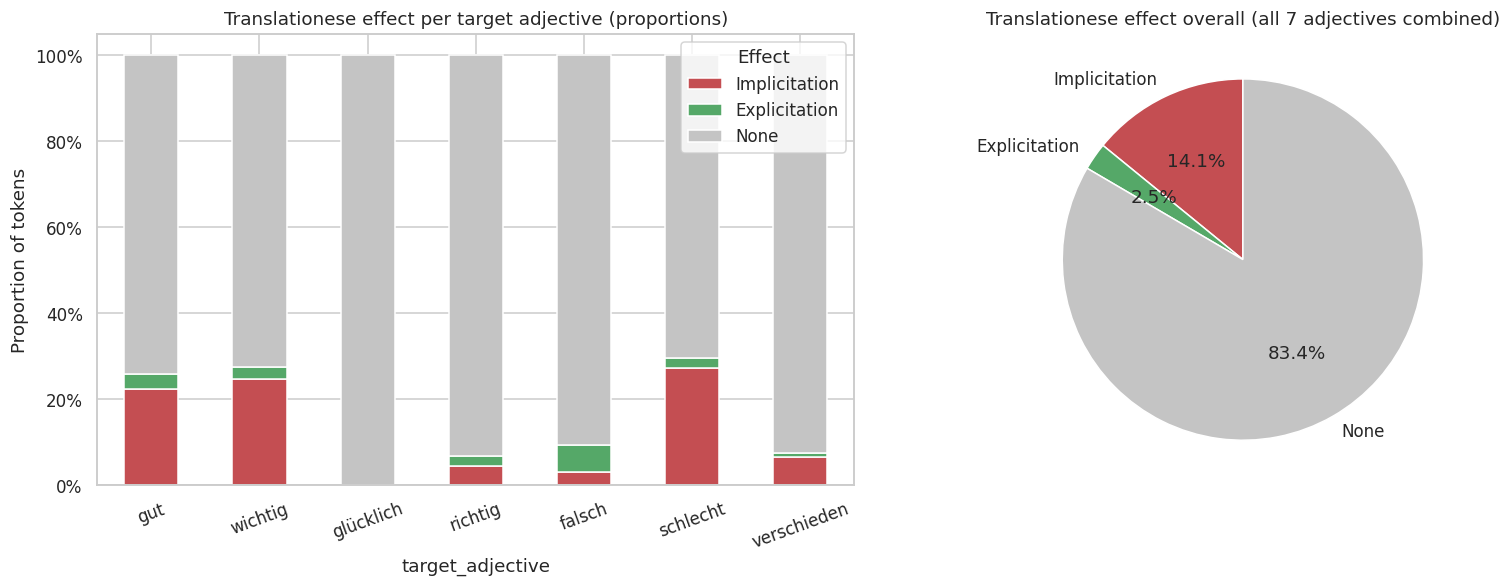

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

eff_prop.plot(kind="bar", stacked=True, ax=axes[0],
              color=["#C44E52", "#55A868", "#C4C4C4"])
axes[0].set_ylabel("Proportion of tokens")
axes[0].set_title("Translationese effect per target adjective (proportions)")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(title="Effect", loc="upper right")
axes[0].tick_params(axis="x", rotation=20)

overall = eff_ct.sum(axis=0)
axes[1].pie(overall.values, labels=overall.index, autopct="%1.1f%%",
            colors=["#C44E52", "#55A868", "#C4C4C4"], startangle=90)
axes[1].set_title("Translationese effect overall (all 7 adjectives combined)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task7_translationese_effect.png"))
plt.show()


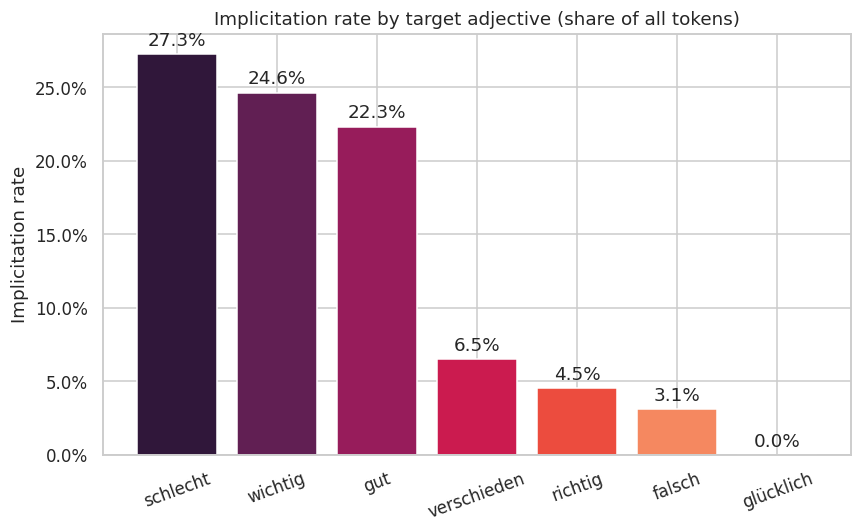

In [11]:

# Implicitation rate specifically (Implicitation / total tokens), per adjective, sorted
implicitation_rate = (eff_ct["Implicitation"] / eff_ct.sum(axis=1)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(implicitation_rate.index, implicitation_rate.values,
              color=sns.color_palette("rocket", len(implicitation_rate)))
ax.set_ylabel("Implicitation rate")
ax.set_title("Implicitation rate by target adjective (share of all tokens)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.bar_label(bars, fmt="%.1f%%", labels=[f"{v*100:.1f}%" for v in implicitation_rate.values], padding=3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task7_implicitation_rate_ranked.png"))
plt.show()



## 8. How translation strategy and translationese effect relate

As a consistency check on the coding scheme itself: `Translationese_effect` should only be
coded when `Translation_strategy` is *Alteration*. The heatmap below confirms this (or shows
any exceptions) across the full dataset.


Translationese_effect_,Explicitation,Implicitation,None
Translation_strategy_,,,
Alteration,11,69,0
Equivalence,1,0,372
Not coded,0,0,36


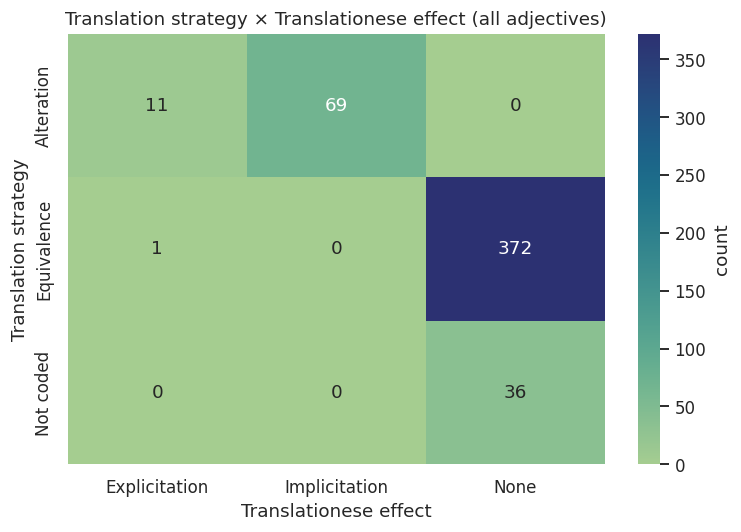

In [12]:

cross = pd.crosstab(strat["Translation_strategy_"], eff["Translationese_effect_"])
display(cross)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cross, annot=True, fmt="d", cmap="crest", ax=ax, cbar_kws={"label": "count"})
ax.set_title("Translation strategy × Translationese effect (all adjectives)")
ax.set_xlabel("Translationese effect")
ax.set_ylabel("Translation strategy")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task8_strategy_vs_effect_heatmap.png"))
plt.show()



## 9. Does evaluative meaning survive the translation? (EN vs. DE evaluativity)

`EN_Evaluative?` / `DE_Evaluative?` code whether the adjective's use in that sentence is
evaluative (expresses a stance) or non-evaluative, in English and German respectively. Here
we check how often that evaluativity status changes between the two languages, and then
specifically how that lines up with rows coded as Implicitation — implicitation is often
expected to *reduce* the explicitness of evaluation, so it's worth seeing whether it also
sometimes flips a sentence from evaluative to non-evaluative altogether.


DE_Evaluative?,Evaluative,Evaluative-not_speaker,Non-evaluative,Not coded
EN_Evaluative?,,,,
Evaluative,394,1,6,0
Evaluative-not_speaker,0,45,0,0
Non-evaluative,7,1,33,0
Not coded,0,0,0,1
Uncertain,1,0,0,0


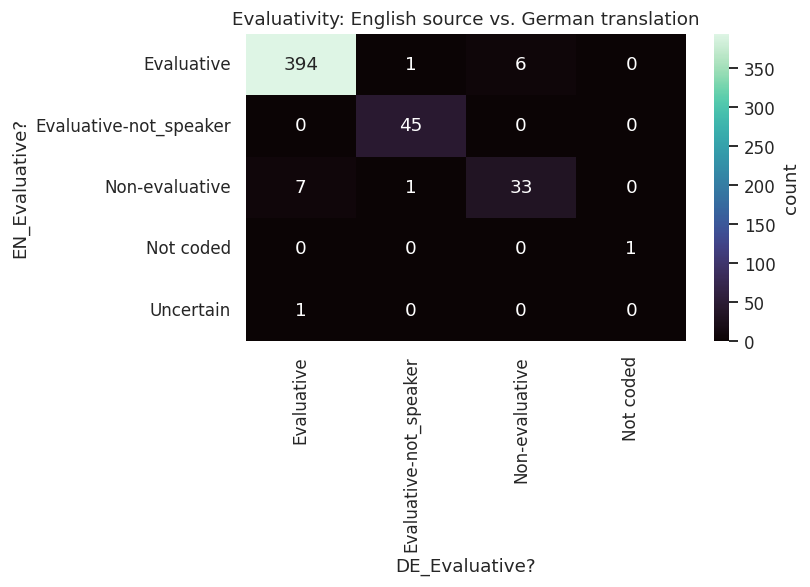

In [13]:

ev = df.copy()
ev["EN_Evaluative?"] = ev["EN_Evaluative?"].fillna("Not coded")
ev["DE_Evaluative?"] = ev["DE_Evaluative?"].fillna("Not coded")

ev_cross = pd.crosstab(ev["EN_Evaluative?"], ev["DE_Evaluative?"])
display(ev_cross)
ev_cross.to_csv(os.path.join(OUTPUT_DIR, "task9_evaluativity_shift.csv"))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(ev_cross, annot=True, fmt="d", cmap="mako", ax=ax, cbar_kws={"label": "count"})
ax.set_title("Evaluativity: English source vs. German translation")
ax.set_xlabel("DE_Evaluative?")
ax.set_ylabel("EN_Evaluative?")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task9_evaluativity_heatmap.png"))
plt.show()


Implicitation rows: 69
evaluativity_changed
False    63
True      6
Name: count, dtype: int64


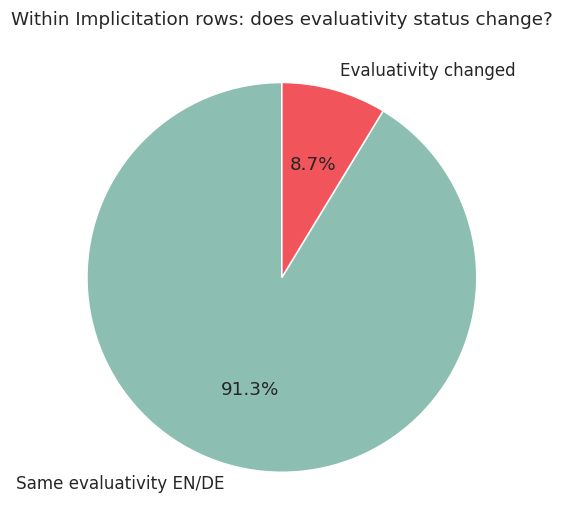

In [14]:

# Among Implicitation rows only: does evaluativity status change?
impl_rows = df[df["Translationese_effect"] == "Implicitation"].copy()
impl_rows["EN_Evaluative?"] = impl_rows["EN_Evaluative?"].fillna("Not coded")
impl_rows["DE_Evaluative?"] = impl_rows["DE_Evaluative?"].fillna("Not coded")
impl_rows["evaluativity_changed"] = impl_rows["EN_Evaluative?"] != impl_rows["DE_Evaluative?"]

print(f"Implicitation rows: {len(impl_rows)}")
print(impl_rows["evaluativity_changed"].value_counts())

fig, ax = plt.subplots(figsize=(5.5, 5))
vc = impl_rows["evaluativity_changed"].value_counts()
ax.pie(vc.values, labels=["Same evaluativity EN/DE" if not v else "Evaluativity changed" for v in vc.index],
       autopct="%1.1f%%", colors=["#8CBEB2", "#F2545B"], startangle=90)
ax.set_title("Within Implicitation rows: does evaluativity status change?")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task9_implicitation_evaluativity_change.png"))
plt.show()



## 10. Attitude type: Appreciation, Judgement, Affect — EN vs. DE, and vs. implicitation

`EN_Attitude_type` / `DE_Attitude_type` classify *what kind* of evaluation is being made
(Appreciation = evaluating things/phenomena, Judgement = evaluating people's behaviour,
Affect = expressing emotion), following the Appraisal framework. First we check how stable
these categories are across languages; then we look specifically at which attitude types
are most associated with implicitation — e.g. is implicitation more common when the original
was an Appreciation than a Judgement?


DE_Attitude_type,Affect,Appreciation,Judgement,Not coded/Non-evaluative
EN_Attitude_type,,,,
Affect,12,1,1,0
Appreciation,0,370,1,5
Judgement,0,0,55,1
Not coded/Non-evaluative,0,5,3,35


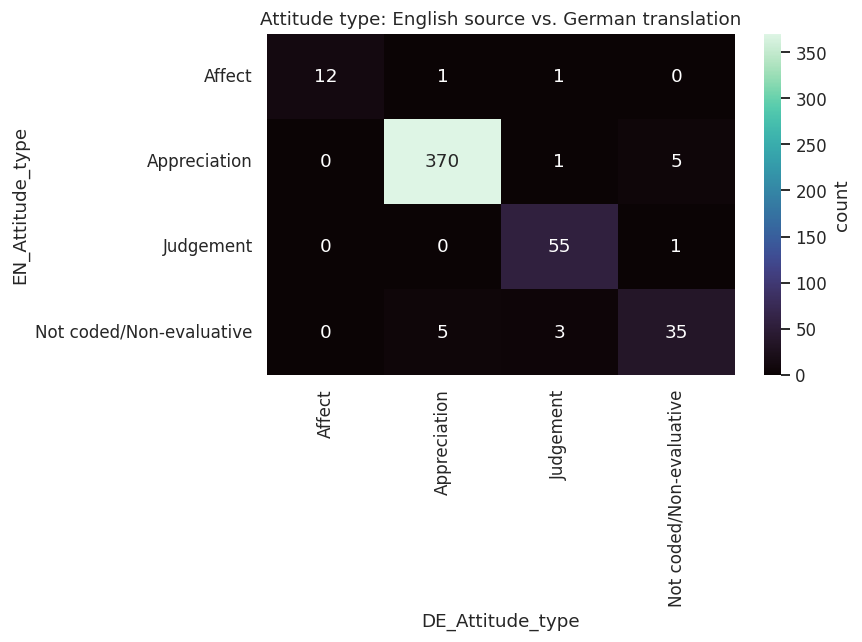

In [15]:

at = df.copy()
at["EN_Attitude_type"] = at["EN_Attitude_type"].fillna("Not coded/Non-evaluative")
at["DE_Attitude_type"] = at["DE_Attitude_type"].fillna("Not coded/Non-evaluative")

at_cross = pd.crosstab(at["EN_Attitude_type"], at["DE_Attitude_type"])
display(at_cross)
at_cross.to_csv(os.path.join(OUTPUT_DIR, "task10_attitude_type_shift.csv"))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(at_cross, annot=True, fmt="d", cmap="mako", ax=ax, cbar_kws={"label": "count"})
ax.set_title("Attitude type: English source vs. German translation")
ax.set_xlabel("DE_Attitude_type")
ax.set_ylabel("EN_Attitude_type")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task10_attitude_type_heatmap.png"))
plt.show()


,n_implicitation_rows
EN_Attitude_type,
Appreciation,56
Judgement,11
Affect,2


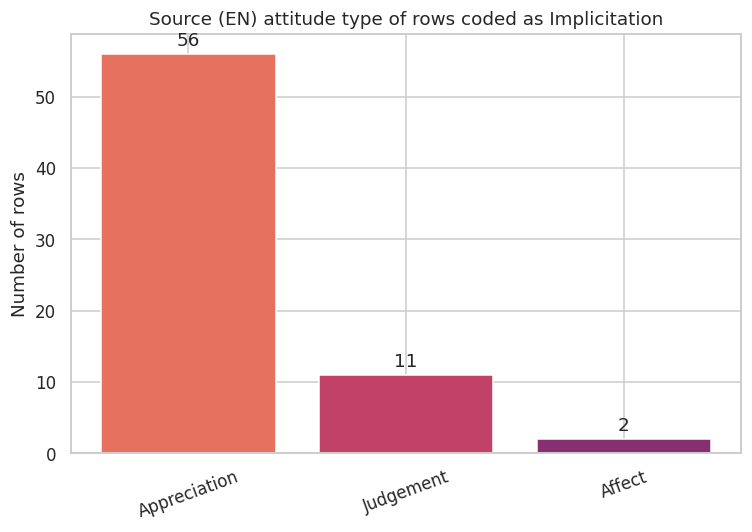

In [16]:

# Attitude type (source, EN) breakdown specifically among Implicitation rows
impl_attitude = df[df["Translationese_effect"] == "Implicitation"]["EN_Attitude_type"].fillna("Not coded").value_counts()
display(impl_attitude.to_frame("n_implicitation_rows"))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(impl_attitude.index, impl_attitude.values,
              color=sns.color_palette("flare", len(impl_attitude)))
ax.set_title("Source (EN) attitude type of rows coded as Implicitation")
ax.set_ylabel("Number of rows")
ax.bar_label(bars, padding=3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task10_implicitation_by_attitude_type.png"))
plt.show()



## 11. Implicitation rate by domain

Does implicitation happen more in some subject domains (e.g. Business, Technology) than
others (e.g. Art, Education)? We compute the implicitation rate per domain across all 7
adjectives combined. Domains with very few tokens overall are noisy, so the underlying
counts are shown alongside the rate.


,n_tokens,n_implicitation,implicitation_rate
Domain,,,
Pol,42,10,0.238095
Edu,40,9,0.225000
His,18,4,0.222222
Med,36,7,0.194444
Ent,28,5,0.178571
Phi,55,9,0.163636
Tech,53,8,0.150943
Bus,61,8,0.131148
Psy,42,4,0.095238


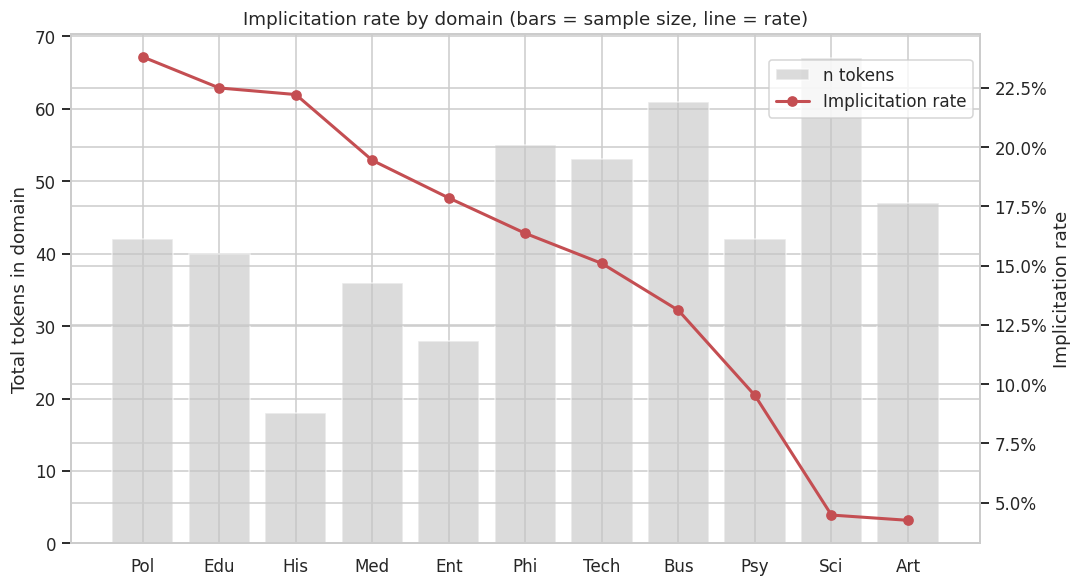

In [17]:

dom = df.copy()
dom["is_implicitation"] = dom["Translationese_effect"] == "Implicitation"

dom_summary = dom.groupby("Domain").agg(
    n_tokens=("is_implicitation", "size"),
    n_implicitation=("is_implicitation", "sum"),
)
dom_summary["implicitation_rate"] = dom_summary["n_implicitation"] / dom_summary["n_tokens"]
dom_summary = dom_summary.sort_values("implicitation_rate", ascending=False)
display(dom_summary)
dom_summary.to_csv(os.path.join(OUTPUT_DIR, "task11_domain_implicitation_rate.csv"))

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax2 = ax1.twinx()

ax1.bar(dom_summary.index, dom_summary["n_tokens"], color="#C4C4C4", alpha=0.6, label="n tokens")
ax1.set_ylabel("Total tokens in domain")

ax2.plot(dom_summary.index, dom_summary["implicitation_rate"], color="#C44E52",
         marker="o", linewidth=2, label="Implicitation rate")
ax2.set_ylabel("Implicitation rate")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax1.set_title("Implicitation rate by domain (bars = sample size, line = rate)")
plt.xticks(rotation=30, ha="right")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task11_domain_implicitation_rate.png"))
plt.show()



## 12. Implicitation rate by speaker gender

The same question, broken down by the gender of the original English speaker: does the
implicitation rate differ between talks given by men vs. women?


,n_tokens,n_implicitation,implicitation_rate
Gender,,,
F,244,35,0.143443
M,245,34,0.138776


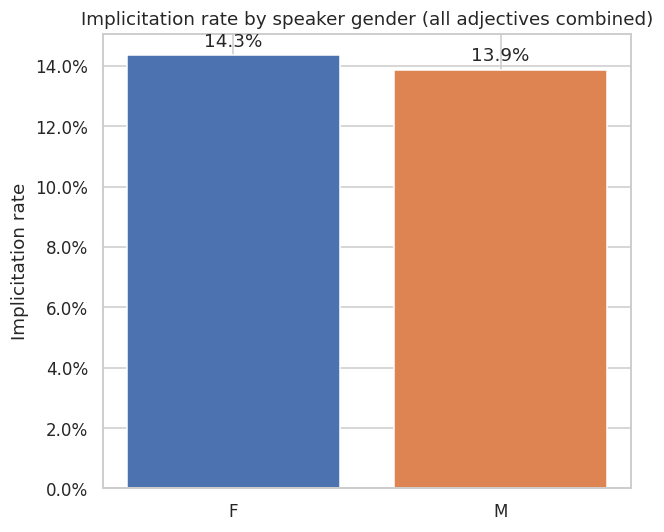

In [18]:

gen = df.copy()
gen["is_implicitation"] = gen["Translationese_effect"] == "Implicitation"

gen_summary = gen.groupby("Gender").agg(
    n_tokens=("is_implicitation", "size"),
    n_implicitation=("is_implicitation", "sum"),
)
gen_summary["implicitation_rate"] = gen_summary["n_implicitation"] / gen_summary["n_tokens"]
display(gen_summary)
gen_summary.to_csv(os.path.join(OUTPUT_DIR, "task12_gender_implicitation_rate.csv"))

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(gen_summary.index, gen_summary["implicitation_rate"],
              color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Implicitation rate")
ax.set_title("Implicitation rate by speaker gender (all adjectives combined)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.bar_label(bars, fmt="%.1f%%", labels=[f"{v*100:.1f}%" for v in gen_summary["implicitation_rate"]], padding=3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "task12_gender_implicitation_rate.png"))
plt.show()



## 13. Export the combined dataset and summary tables

Save the full combined dataset (all 7 adjectives, one row per token) as a single CSV, plus
a compact per-adjective summary table pulling together the key numbers from Tasks 2, 6 and 7.
All files (this one plus every chart/table saved earlier) are written to
`/mnt/user-data/outputs/` for direct use in the write-up.


In [19]:

df.to_csv(os.path.join(OUTPUT_DIR, "implicitation_dataset_combined.csv"), index=False)

summary = pd.DataFrame({
    "n_tokens": counts,
    "n_distinct_EN_lemmas": diversity["n_distinct_EN_lemmas"],
    "pct_default_equivalent_contamination": sanity["pct_default_equivalent"],
    "pct_alteration": strat_prop.get("Alteration", pd.Series(0, index=TARGET_ADJECTIVES)) * 100,
    "pct_implicitation": eff_prop["Implicitation"] * 100,
    "pct_explicitation": eff_prop["Explicitation"] * 100,
}).round(1)

display(summary)
summary.to_csv(os.path.join(OUTPUT_DIR, "task13_master_summary_table.csv"))
print("\nAll outputs written to:", OUTPUT_DIR)


,n_tokens,n_distinct_EN_lemmas,pct_default_equivalent_contamination,pct_alteration,pct_implicitation,pct_explicitation
target_adjective,,,,,,
gut,112,57,0.0,25.0,22.3,3.6
wichtig,69,35,1.4,27.5,24.6,2.9
glücklich,3,3,0.0,0.0,0.0,0.0
richtig,44,25,0.0,6.8,4.5,2.3
falsch,32,15,3.1,9.4,3.1,6.2
schlecht,44,24,0.0,29.5,27.3,2.3
verschieden,185,14,81.6,7.6,6.5,1.1



All outputs written to: /mnt/user-data/outputs



## 14. Template: comparing against the "normal" (non-implicitation) translations dataset

The next step in the wider study is comparing these implicitation-rate results to the same
7 adjectives drawn from the **normal** translation dataset (i.e. sentences where the source
English adjective *is* the default equivalent, or just a general sample of these 7 German
adjectives in translation, not specifically curated for implicitation candidates). That file
isn't part of this notebook yet — the cell below is a ready-to-run template for once it is
available. It expects a second combined dataset with at least a `target_adjective` and a
`Translationese_effect` column in the same coding scheme used here.


In [20]:

# --- Template for later use -------------------------------------------------
# 1. Point this at the "normal" translations dataset once available, e.g.:
# NORMAL_DATA_DIR = "German translations - normal dataset"
# normal_frames = []
# for adj in TARGET_ADJECTIVES:
#     d = pd.read_excel(os.path.join(NORMAL_DATA_DIR, f"{adj}_normal.xlsx"))
#     d["target_adjective"] = adj
#     normal_frames.append(d)
# normal_df = pd.concat(normal_frames, ignore_index=True)
#
# 2. Compute the same implicitation-rate summary as Task 7 for the normal dataset:
# normal_df["Translationese_effect_"] = normal_df["Translationese_effect"].fillna("None")
# normal_eff_ct = pd.crosstab(normal_df["target_adjective"], normal_df["Translationese_effect_"]).reindex(TARGET_ADJECTIVES)
# normal_rate = normal_eff_ct["Implicitation"] / normal_eff_ct.sum(axis=1)
#
# 3. Compare side by side with the implicitation-dataset rate computed in Task 7:
# comparison = pd.DataFrame({
#     "implicitation_dataset_rate": implicitation_rate,
#     "normal_dataset_rate": normal_rate,
# })
# comparison["difference"] = comparison["implicitation_dataset_rate"] - comparison["normal_dataset_rate"]
# display(comparison)
#
# comparison.plot(kind="bar", y=["implicitation_dataset_rate", "normal_dataset_rate"], figsize=(9, 5))
# plt.ylabel("Implicitation rate")
# plt.title("Implicitation rate: special dataset vs. normal dataset")
# plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
# plt.tight_layout()
# plt.show()
print("Template only — fill in the path to the normal-translations dataset to run this comparison.")


Template only — fill in the path to the normal-translations dataset to run this comparison.
